In [ ]:
#EX1

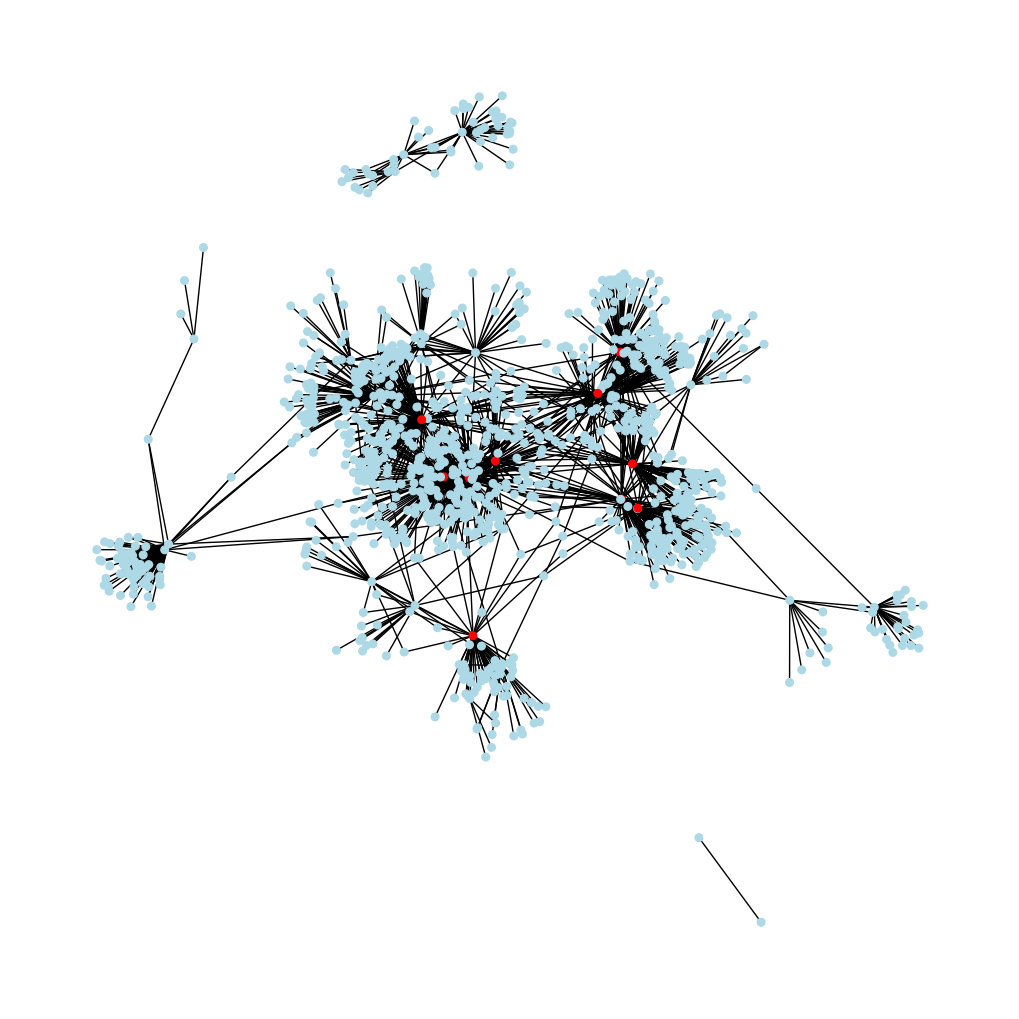

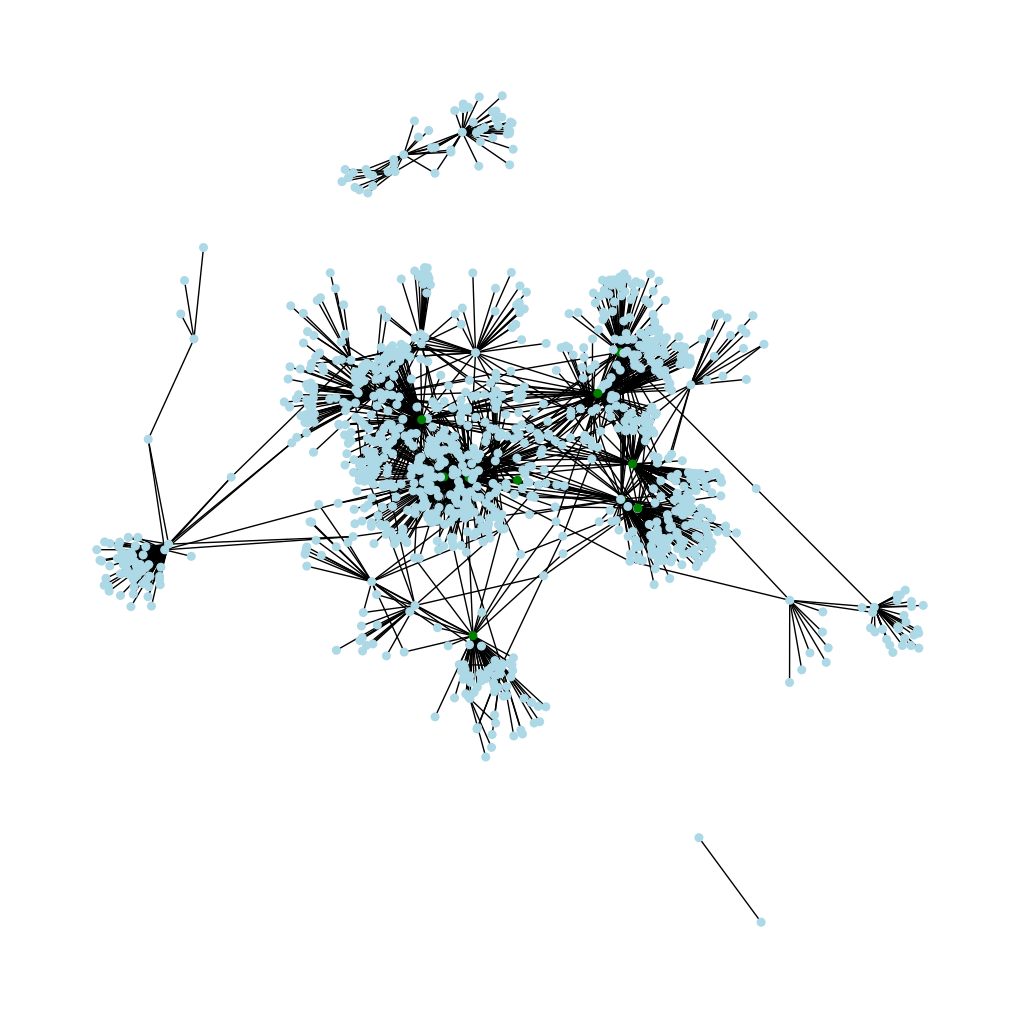

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import LocalOutlierFactor

limit = 1500
fname = "ca-AstroPh.txt"

G = nx.Graph()
with open(fname, "r") as f:
    for idx, line in enumerate(f):
        if idx >= limit:
            break
        u, v = map(int, line.split())
        if G.has_edge(u, v):
            G[u][v]["weight"] += 1
        else:
            G.add_edge(u, v, weight=1)

Ni, Ei, Wi, Lw = {}, {}, {}, {}

for v in G.nodes():
    eg = nx.ego_graph(G, v, radius=1)
    Ni[v] = eg.number_of_nodes() - 1
    Ei[v] = eg.number_of_edges()
    Wi[v] = sum(attr["weight"] for _, _, attr in eg.edges(data=True))
    if eg.number_of_nodes() > 1:
        M = nx.to_numpy_array(eg, weight="weight")
        Lw[v] = float(np.linalg.eigvalsh(M).max())
    else:
        Lw[v] = 0.0

nx.set_node_attributes(G, Ni, "Ni")
nx.set_node_attributes(G, Ei, "Ei")
nx.set_node_attributes(G, Wi, "Wi")
nx.set_node_attributes(G, Lw, "Lambda_w")

valid_nodes = [v for v in G.nodes() if Ni[v] > 0 and Ei[v] > 0]
X = np.log(np.array([Ni[v] for v in valid_nodes], dtype=float)).reshape(-1, 1)
Y = np.log(np.array([Ei[v] for v in valid_nodes], dtype=float))

reg = LinearRegression()
reg.fit(X, Y)

theta = float(reg.coef_[0])
C = float(np.exp(reg.intercept_))

oddball = {}
for v in valid_nodes:
    y_true = float(Ei[v])
    y_hat = C * (float(Ni[v]) ** theta)
    oddball[v] = (max(y_true, y_hat) / min(y_true, y_hat)) * np.log(abs(y_true - y_hat) + 1.0)

top10_oddball = sorted(oddball, key=oddball.get, reverse=True)[:10]

pos = nx.spring_layout(G, seed=4)

c1 = ["red" if v in top10_oddball else "lightblue" for v in G.nodes()]
plt.figure(figsize=(10, 10))
nx.draw(G, pos=pos, node_color=c1, node_size=30, with_labels=False)
plt.show()

X_lof = np.array([[Ei[v], Ni[v]] for v in valid_nodes], dtype=float)
lof = LocalOutlierFactor(n_neighbors=50)
lof.fit(X_lof)
lof_raw = -lof.negative_outlier_factor_

lof_norm = (lof_raw - lof_raw.min()) / (lof_raw.max() - lof_raw.min())
od_vals = np.array([oddball[v] for v in valid_nodes], dtype=float)
od_norm = (od_vals - od_vals.min()) / (od_vals.max() - od_vals.min())

combo = {v: float(od_norm[i] + lof_norm[i]) for i, v in enumerate(valid_nodes)}
top10_combo = sorted(combo, key=combo.get, reverse=True)[:10]

c2 = ["green" if v in top10_combo else "lightblue" for v in G.nodes()]
plt.figure(figsize=(10, 10))
nx.draw(G, pos=pos, node_color=c2, node_size=30, with_labels=False)
plt.show()


In [ ]:
#EX2

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def oddball_scores_from_pairs(x_raw, y_raw, eps=1e-12):
    keys = list(x_raw.keys())
    keep = [k for k in keys if x_raw[k] > 0 and y_raw[k] > 0]
    X = np.log(np.array([x_raw[k] for k in keep], dtype=float)).reshape(-1, 1)
    Y = np.log(np.array([y_raw[k] for k in keep], dtype=float))

    lr = LinearRegression()
    lr.fit(X, Y)

    theta = float(lr.coef_[0])
    C = float(np.exp(lr.intercept_))

    s = {}
    for k in keep:
        x = float(x_raw[k])
        y = float(y_raw[k])
        yhat = C * (x ** theta)
        ratio = max(y, yhat) / max(min(y, yhat), eps)
        s[k] = ratio * np.log(abs(y - yhat) + 1.0)
    return s


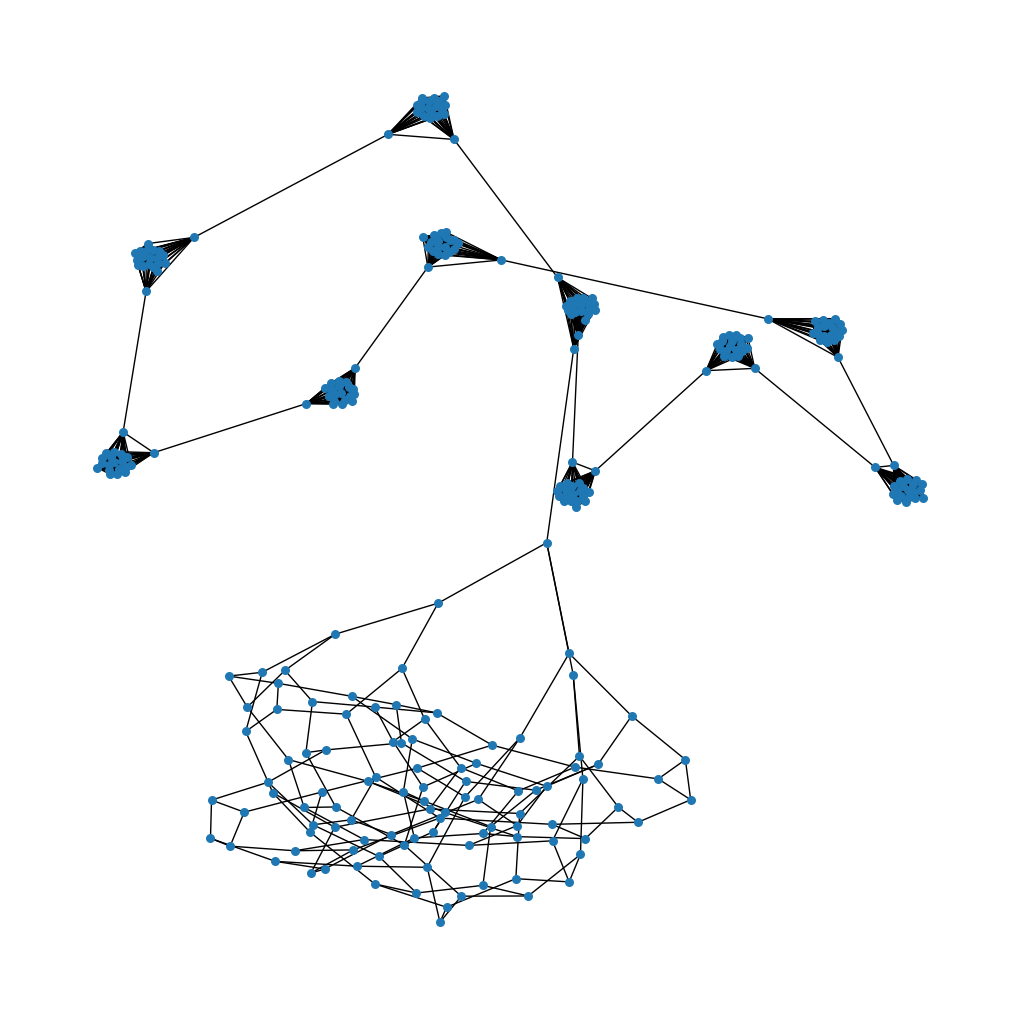

In [4]:
#Building merged graph (regular + caveman)
np.random.seed(7)

G_reg = nx.random_regular_graph(d=3, n=100)
G_clq = nx.connected_caveman_graph(l=10, k=20)

G_merge = nx.union(G_reg, G_clq, rename=("R_", "C_"))

for u, v in G_merge.edges():
    G_merge[u][v]["weight"] = 1

all_nodes = list(G_merge.nodes())
while not nx.is_connected(G_merge):
    a, b = np.random.choice(all_nodes, 2, replace=False)
    if not G_merge.has_edge(a, b):
        G_merge.add_edge(a, b, weight=1)

pos_merge = nx.spring_layout(G_merge, seed=2)

plt.figure(figsize=(10, 10))
nx.draw(G_merge, pos=pos_merge, node_size=30, with_labels=False)
plt.show()


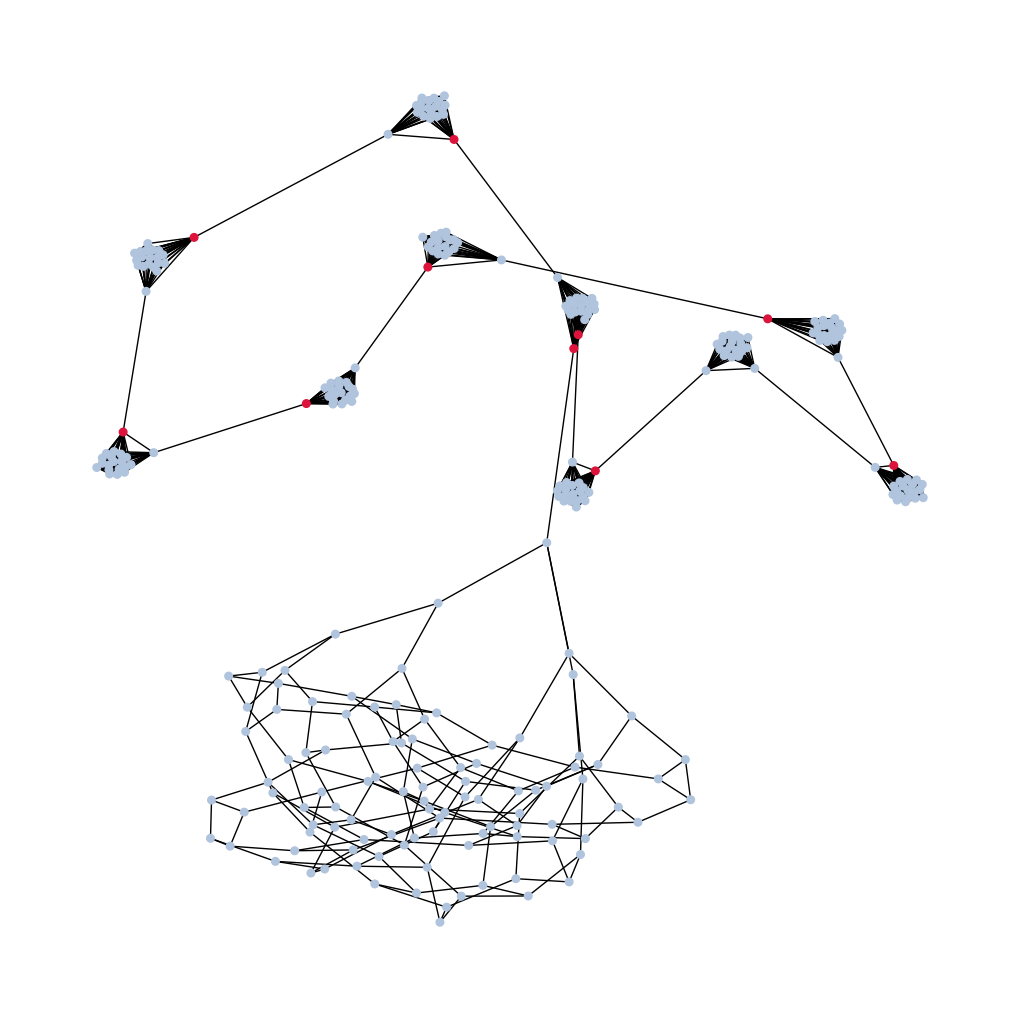

In [5]:
#Computing Ni/Ei, score (Ei vs Ni), highlighting top 10
Ni = {}
Ei = {}

for v in G_merge.nodes():
    eg = nx.ego_graph(G_merge, v, radius=1)
    Ni[v] = eg.number_of_nodes() - 1
    Ei[v] = eg.number_of_edges()

scores_clique = oddball_scores_from_pairs(Ni, Ei)
top10_clique = sorted(scores_clique, key=scores_clique.get, reverse=True)[:10]

colors_clique = ["crimson" if v in top10_clique else "lightsteelblue" for v in G_merge.nodes()]

plt.figure(figsize=(10, 10))
nx.draw(G_merge, pos=pos_merge, node_color=colors_clique, node_size=30, with_labels=False)
plt.show()


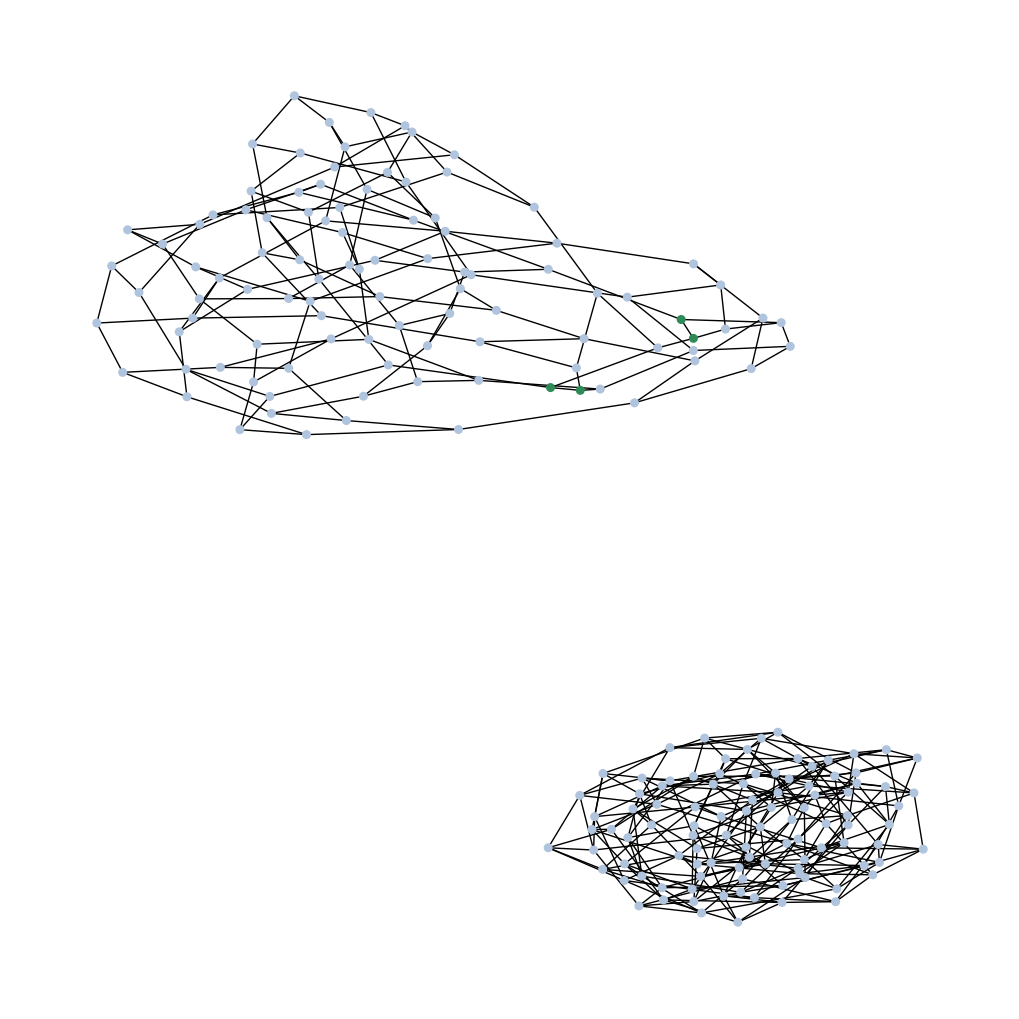

In [6]:
#HeavyVicinity anomalies (Wi vs Ei), highlighting top 4
np.random.seed(9)

G3 = nx.random_regular_graph(d=3, n=100)
G5 = nx.random_regular_graph(d=5, n=100)

G_hv = nx.union(G3, G5, rename=("A_", "B_"))

for u, v in G_hv.edges():
    G_hv.add_edge(u, v, weight=1)

centers = np.random.choice(list(G_hv.nodes()), 2, replace=False)
for c in centers:
    eg = nx.ego_graph(G_hv, c, radius=1)
    for u, v in eg.edges():
        G_hv[u][v]["weight"] += 10

Wi = {}
Ei2 = {}

for v in G_hv.nodes():
    eg = nx.ego_graph(G_hv, v, radius=1)
    Ei2[v] = eg.number_of_edges()
    Wi[v] = sum(attr.get("weight", 1) for _, _, attr in eg.edges(data=True))

scores_heavy = oddball_scores_from_pairs(Ei2, Wi)
top4_heavy = sorted(scores_heavy, key=scores_heavy.get, reverse=True)[:4]

pos_hv = nx.spring_layout(G_hv, seed=4)
colors_heavy = ["seagreen" if v in top4_heavy else "lightsteelblue" for v in G_hv.nodes()]

plt.figure(figsize=(10, 10))
nx.draw(G_hv, pos=pos_hv, node_color=colors_heavy, node_size=30, with_labels=False)
plt.show()


In [13]:
#EX3

In [1]:
import numpy as np
import scipy.io
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from sklearn.metrics import roc_auc_score
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_scipy_sparse_matrix

device = torch.device("cpu")

data = scipy.io.loadmat("ACM.mat")

X = torch.tensor(data["Attributes"].toarray(), dtype=torch.float32).to(device)
y = torch.tensor(data["Label"].reshape(-1), dtype=torch.long).to(device)

A_sparse = data["Network"]
edge_index, _ = from_scipy_sparse_matrix(A_sparse)
edge_index = edge_index.to(device)

n_nodes, n_feats = X.shape


class Encoder(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.c1 = GCNConv(in_dim, 128)
        self.c2 = GCNConv(128, 64)

    def forward(self, x, edge_index):
        h = F.relu(self.c1(x, edge_index))
        z = F.relu(self.c2(h, edge_index))
        return z


class AttrDecoder(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        self.c1 = GCNConv(64, 128)
        self.c2 = GCNConv(128, out_dim)

    def forward(self, z, edge_index):
        h = F.relu(self.c1(z, edge_index))
        return self.c2(h, edge_index)


class StructDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.c = GCNConv(64, 64)

    def forward(self, z, edge_index):
        return F.relu(self.c(z, edge_index))


class GAE(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.enc = Encoder(in_dim)
        self.dec_x = AttrDecoder(in_dim)
        self.dec_s = StructDecoder()

    def forward(self, x, edge_index):
        z = self.enc(x, edge_index)
        x_hat = self.dec_x(z, edge_index)
        z_s = self.dec_s(z, edge_index)
        return z, x_hat, z_s


model = GAE(n_feats).to(device)
optimizer = Adam(model.parameters(), lr=0.004)

alpha = 0.8

A_coo = A_sparse.tocoo()
Ai = torch.tensor(np.vstack([A_coo.row, A_coo.col]), dtype=torch.long).to(device)
Av = torch.tensor(A_coo.data, dtype=torch.float32).to(device)

A_norm_sq = torch.sum(Av * Av)  # avoids dense A construction


def struct_loss(z):
    G = z.t() @ z                      # avoids forming Z @ Z.T
    zz = torch.sum(G * G)
    zi = z[Ai[0]]
    zj = z[Ai[1]]
    tr = torch.sum((zi * zj).sum(dim=1) * Av)
    return A_norm_sq + zz - 2.0 * tr   # exact Frobenius form


def loss_fn(X, X_hat, z_s):
    return alpha * torch.sum((X - X_hat) ** 2) + \
           (1 - alpha) * struct_loss(z_s)


src = Ai[0]
dst = Ai[1]
deg = torch.bincount(src, minlength=n_nodes).clamp(min=1)


def anomaly_scores(X, X_hat, z_s):
    attr_err = torch.norm(X - X_hat, dim=1)

    zi = z_s[src]
    zj = z_s[dst]
    e_pos = (1.0 - (zi * zj).sum(dim=1)) ** 2
    pos_sum = torch.zeros(n_nodes, device=device).index_add_(0, src, e_pos)

    neg_dst = torch.randint(0, n_nodes, (src.numel(),), device=device)
    zn = z_s[neg_dst]
    e_neg = (zn * z_s[src]).sum(dim=1) ** 2
    neg_sum = torch.zeros(n_nodes, device=device).index_add_(0, src, e_neg)

    struct_err = (pos_sum + neg_sum) / (2 * deg)  # sampled non-edges for speed
    return alpha * attr_err + (1 - alpha) * struct_err


epochs = 50

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    z, X_hat, z_s = model(X, edge_index)
    loss = loss_fn(X, X_hat, z_s)

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            z, X_hat, z_s = model(X, edge_index)
            scores = anomaly_scores(X, X_hat, z_s)
            auc = roc_auc_score(y.cpu().numpy(), scores.cpu().numpy())
        print(f"Epoch {epoch:02d} | Loss {loss.item():.4f} | ROC AUC {auc:.4f}")


Epoch 05 | Loss 40645.3203 | ROC AUC 0.7468
Epoch 10 | Loss 40091.4531 | ROC AUC 0.7530
Epoch 15 | Loss 39809.7852 | ROC AUC 0.7475
Epoch 20 | Loss 39748.1094 | ROC AUC 0.7476
Epoch 25 | Loss 39712.6641 | ROC AUC 0.7475
Epoch 30 | Loss 39686.3164 | ROC AUC 0.7475
Epoch 35 | Loss 39655.5938 | ROC AUC 0.7475
Epoch 40 | Loss 39623.2227 | ROC AUC 0.7477
Epoch 45 | Loss 39587.1016 | ROC AUC 0.7475
Epoch 50 | Loss 39550.3516 | ROC AUC 0.7475
